# Ocean heat content drift — Full-CPL spin-up + piControl

Figures:
* `Full-CPL_OHC_allDepths_annual_0-2500.pdf`

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os, re, glob, warnings, string
import numpy as np
import xarray as xr
import cftime
import contextlib
import pandas as pd 

from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, FixedLocator

from util.ctrl_plotting import OHCDriftPlotter
from util.ctrl_processing import OHCBuilder
from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ohc_ts"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ohc_ts"                # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPERIMENT     = "Full-CPL"    # experiment analysed (spin-up followed by its piControl)
CTRL_YEARS     = (0, 2500)     # combined spin-up + piControl model years (axes, cache/figure names)
SPINUP_MARKERS = (350, 2000)   # vertical markers; trends fit from the first, decay fit up to the second


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts


## 1 OHC by layer

In [4]:
data_dir    = MODEL_ROOT
file_depth  = f"{OUTPUT_ROOT}/data/grid/depth.nc"
out_dir     = DATA_DIR
os.makedirs(out_dir, exist_ok=True)

experiment = EXPERIMENT
if 'run_dict' not in globals():
    raise RuntimeError("[ERROR] 'run_dict' is not defined.")
if experiment not in run_dict:
    raise ValueError(f"[ERROR] '{experiment}' not in run_dict.")
spinup_name    = run_dict[experiment]["spin-up"]["name"]
picontrol_name = run_dict[experiment]["piControl"]["name"]

# ---------------- config ----------------
subdir           = "post/time_series"
var_name         = "OHC"
var_unit         = "1e22 J"
var_fact         = 1e-22
file_stem        = "mpasTimeSeriesOcean"
xr_engine        = "netcdf4"
suffix           = "annual"
spinup_period    = list(CTRL_YEARS)
filter_window    = 11
trend_windows    = (10, 30)
add_per_decade   = True
sequence         = "append"
force_reprocess  = True
strict           = True

region        = "Global"
regind        = 6
ohc_layer_lab = ("0_bottom", "0_700m", "700m_2000m", "2000m_bottom")
ohc_layer_int = ("0-6000", "0-700", "700-2000", "2000-6000")
ohc_ref_temp  = None

band_to_interval = dict(zip(ohc_layer_lab, ohc_layer_int))

# ---------------- per-band combined diagnostics ----------------
for band in ohc_layer_lab:
    var_band = f"OHC_{band}"
    # ---------------- prebuilt annual files ----------------
    spinup_annual_nc = os.path.join(out_dir, f"{spinup_name}_{var_band}_{region}_timeseries_{suffix}.nc")
    pctl_annual_nc   = os.path.join(out_dir, f"{picontrol_name}_{var_band}_{region}_timeseries_{suffix}.nc")

    # If the annual files for this band don't exist, derive and write them now
    if not (os.path.exists(spinup_annual_nc) and os.path.exists(pctl_annual_nc)):
        print(f"[INFO] Building annual files for {var_band} from raw MPAS…")
        builder_band_deriv = OHCBuilder(
            base_dir=data_dir,
            spinup_name=spinup_name,
            picontrol_name=picontrol_name,
            subdir=subdir,
            file_stem=file_stem,
            xr_engine=xr_engine,
            var_name=var_name,              # derive OHC for THIS single band
            var_unit=var_unit,
            var_fact=var_fact,           # e.g., 1e-22 for "1e22 J"
            force_reprocess=force_reprocess,
            file_depth=file_depth,
            region_id=regind,
            ohc_layer_lab=band,          # SINGLE band label (e.g., "0_700m")
            ohc_layer_int=band_to_interval[band],  # e.g., "0-700"
            ohc_ref_temp=ohc_ref_temp,
        )

        paths_band = builder_band_deriv.build_sources(
            out_dir=out_dir,
            var_name=var_band,  # use OHC_<band> in the filenames
            suffix=suffix
        )
        spinup_annual_nc = paths_band["spinup"]
        pctl_annual_nc   = paths_band["piControl"]
        print(f"[OK] Wrote annual band files: {spinup_annual_nc} | {pctl_annual_nc}")

    if not (os.path.exists(spinup_annual_nc) and os.path.exists(pctl_annual_nc)):
        raise FileNotFoundError("[ERROR] Annual OHC files not found. Please build them first.")

    combined_band_nc = os.path.join(
        out_dir,
        f"{var_band}_{experiment}_combined_{suffix}_{spinup_period[0]}-{spinup_period[1]}.nc"
    )

    print(f"[INFO] Processing {var_band} → {combined_band_nc}")
    builder_band = OHCBuilder(
        base_dir=data_dir,
        spinup_name=spinup_name,
        picontrol_name=picontrol_name,
        subdir=subdir,
        file_stem=file_stem,
        xr_engine=xr_engine,
        var_name=var_name,          # target this band variable
        var_unit=var_unit,
        var_fact=var_fact,
        force_reprocess=force_reprocess,
        file_depth=file_depth,
        region_id=regind,
        ohc_layer_lab=ohc_layer_lab,
        ohc_layer_int=ohc_layer_int,
        ohc_ref_temp=ohc_ref_temp,
    )

    builder_band.build_combined_tidy(
        spinup_nc=spinup_annual_nc,
        pctl_nc=pctl_annual_nc,
        combined_tidy_nc=combined_band_nc,
        filter_window=filter_window,
        trend_windows=trend_windows,
        add_per_decade=add_per_decade,
        sequence=sequence,
        force=force_reprocess,
        strict=True,
    )
    print(f"[OK] Wrote combined tidy diagnostics: {combined_band_nc}")

print("[DONE] All bands processed.")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[INFO] Building annual files for OHC_0_bottom from raw MPAS…
[OK] Wrote annual band files: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ohc_ts/20231209.v3.LR.piControl-spinup.chrysalis_OHC_0_bottom_timeseries_annual.nc | /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ohc_ts/v3.LR.piControl_OHC_0_bottom_timeseries_annual.nc
[INFO] Processing OHC_0_bottom → /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ohc_ts/OHC_0_bottom_Full-CPL_combined_annual_0-2500.nc
[OK] Wrote combined tidy diagnostics: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ohc_ts/OHC_0_bottom_Full-CPL_combined_annual_0-2500.nc
[INFO] Building annual files for OHC_0_700m from raw MPAS…
[OK] Wrote annual band files: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/ohc_ts/20231209.v3.LR.piControl-spinup.chrysalis_OHC_0_700m_timeseries_annual.nc | /lcrc/gro

## 2 Drift figure

[INFO] Plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts/Full-CPL_OHC_0_bottom_annual_0-2500.pdf
[INFO] Plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts/Full-CPL_OHC_0_700m_annual_0-2500.pdf
[INFO] Plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts/Full-CPL_OHC_700m_2000m_annual_0-2500.pdf
[INFO] Plot generated: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts/Full-CPL_OHC_2000m_bottom_annual_0-2500.pdf


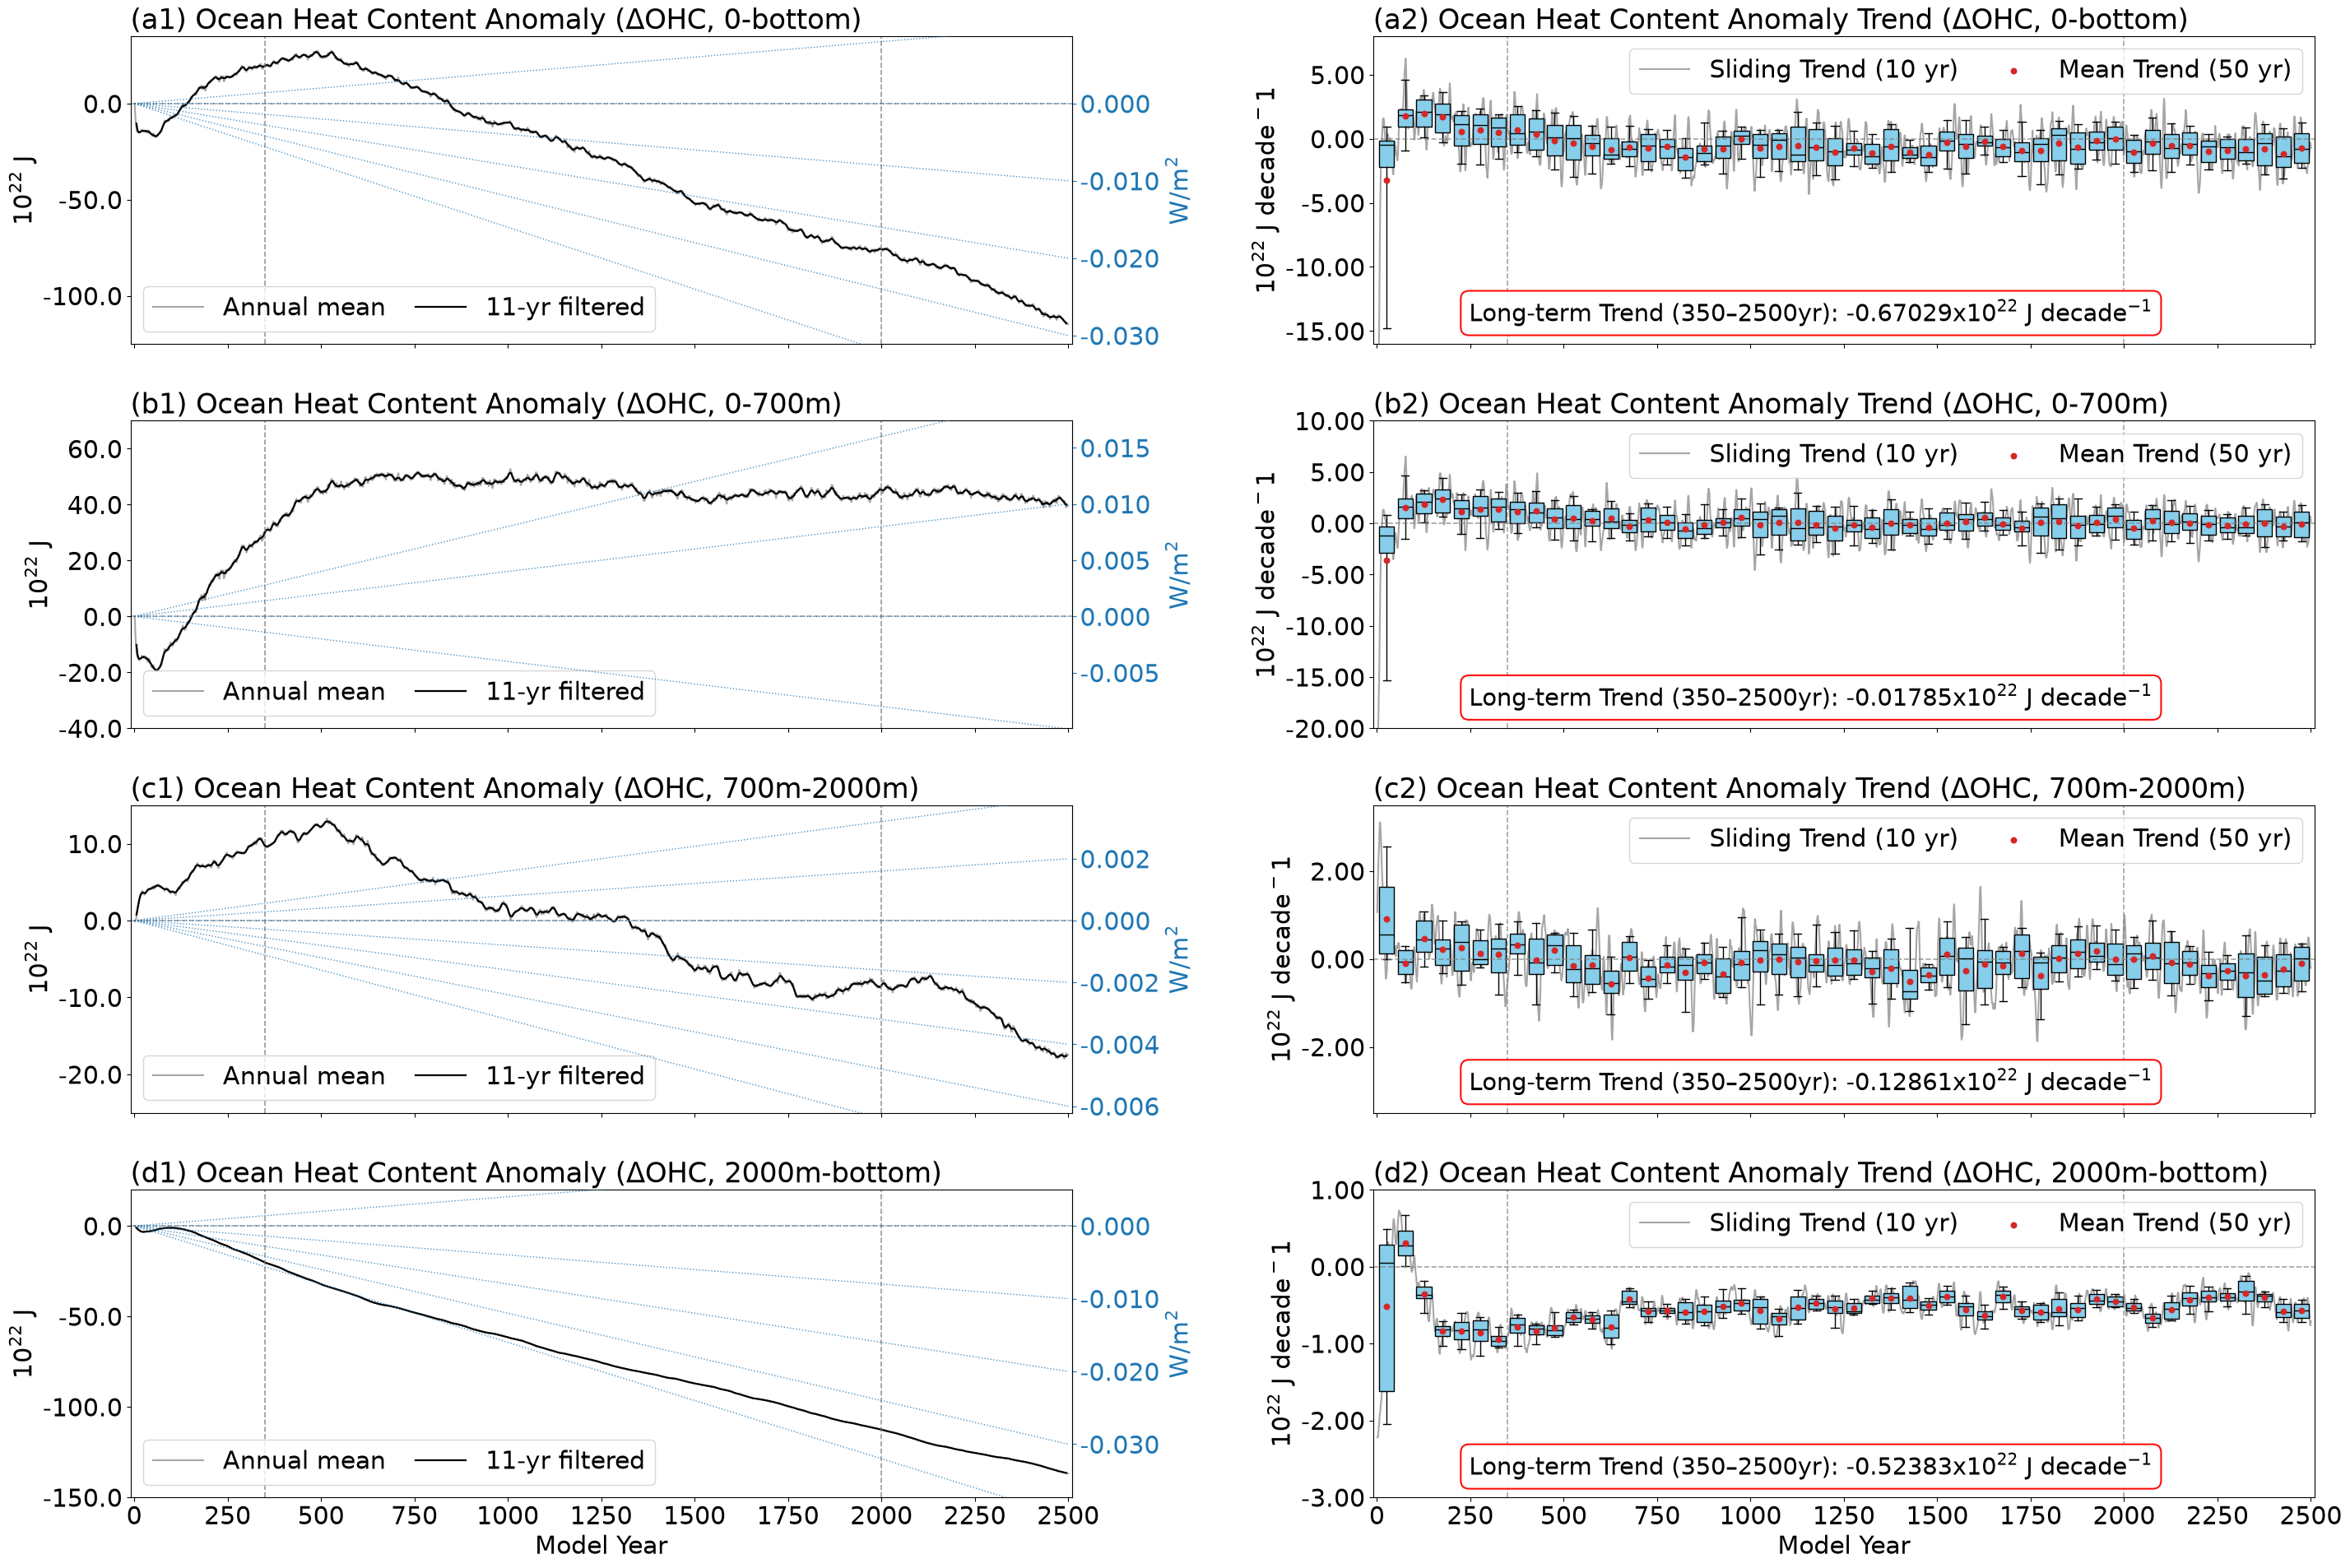

[PLOT] Saved: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts/Full-CPL_OHC_allDepths_annual_0-2500.pdf
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_ts


In [5]:
data_dir    = MODEL_ROOT
out_dir     = DATA_DIR
fig_dir     = FIG_DIR  # or os.path.join(results_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# === Experiment & plot span ===
experiment    = EXPERIMENT
plot_syear    = CTRL_YEARS[0]
plot_eyear    = CTRL_YEARS[1]
spinup_period = SPINUP_MARKERS      # vertical markers
suffix        = "annual"

# === Variable (SST) ===
var_dict = {
    "OHC_0_bottom": {
        "name"  : "OHC",
        "label" : "Ocean Heat Content Anomaly",
        "unit"  : r"$10^{22}$ J",
        "key"   : "mpasTimeSeriesOcean",
        "min"   : -125.0,
        "max"   :  35.0,
        "dmin"  : -16,
        "dmax"  :   8,
        "layer" :  r"$\Delta$OHC, 0-bottom"
    },
    "OHC_0_700m": {
        "name"  : "OHC",
        "label" : "Ocean Heat Content Anomaly",
        "unit"  : r"$10^{22}$ J",
        "key"   : "mpasTimeSeriesOcean",
        "min"   : -40.0,
        "max"   :  70.0,
        "dmin"  : -20,
        "dmax"  :  10,
        "layer" :  r"$\Delta$OHC, 0-700m"
    },
    "OHC_700m_2000m": {
        "name"  : "OHC",
        "label" : "Ocean Heat Content Anomaly",
        "unit"  : r"$10^{22}$ J",
        "key"   : "mpasTimeSeriesOcean",
        "min"   : -25.0,
        "max"   :  15.0,
        "dmin"  : -3.5,
        "dmax"  :  3.5,
        "layer" :  r"$\Delta$OHC, 700m-2000m"
    },
    "OHC_2000m_bottom": {
        "name"  : "OHC",
        "label" : "Ocean Heat Content Anomaly",
        "unit"  : r"$10^{22}$ J",
        "key"   : "mpasTimeSeriesOcean",
        "min"   : -150.0,
        "max"   :  20.0,
        "dmin"  : -3,
        "dmax"  :  1,
        "layer" :  r"$\Delta$OHC, 2000m-bottom"
    },
}

window = 10            # sliding-trend window to display
box_window = 50
filter_window = 11
nxlab = 250
show_filter = True
show_decay = False
legend_one_row=True
fig_id = 0

# below is used to construct equivalent radiative flux lines to the OHC
sec_per_year = 365.0 * 24.0 * 3600.0
flux_area="ocean"                 # regional: ocean
flux_lines=[-0.03,-0.02,-0.01,0.01,0.02,0.03]
show_flux_axis=True
flux_anchor_year=plot_syear
flux_anchor_value=0.0
flux_ref_year=plot_eyear          # makes right axis consistent with whole plot span
flux_style=":"
flux_lw=1
flux_alpha=0.8
# following area is used by mpas_analysis
flux_area_m2 = 4. * np.pi * 6.37122e6**2

plot_combined = True

if plot_combined: 
    figsize = (28,24)
    fontz = 23
    nrows = 1
    ncols = 2
    do_save=False
    do_show=False
    do_close=False
    nrows = len(var_dict)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex="col")
else:
    figsize = (24,4)
    fontz = 18
    nrows = 1
    ncols = 1
    do_save=True
    do_show=True
    do_close=True
    fig=None
    axes=None

# Trend range box 
show_trend_range_box = True 
trend_mode = "full_period",
trend_fit_range = (spinup_period[0],plot_eyear)        # e.g., (syear, eyear) or (spinup_markers[0], eyear)
use_filtered_for_trend = True  # use yf if available
trend_text_position_dict = {
    meta['name']: {'x': 0.02, 'y': 0.98}
    for meta in var_dict.values()
}
# Override specific variables with custom positions
trend_text_position_dict.update({
    'OHC_0_bottom':      {'x': 0.465, 'y': 0.10},
    'OHC_0_700m':        {'x': 0.465, 'y': 0.10},
    'OHC_700m_2000m':    {'x': 0.465, 'y': 0.10},
    'OHC_2000m_bottom':  {'x': 0.465, 'y': 0.10},
}) 

for i, var_name in enumerate(var_dict.keys()):
    fid = fig_id + i
    trend_x = trend_text_position_dict[var_name]['x']
    trend_y = trend_text_position_dict[var_name]['y']

    combined_tidy = os.path.join(
        out_dir, f"{var_name}_{experiment}_combined_{suffix}_{plot_syear}-{plot_eyear}.nc"
    )
    if not os.path.isfile(combined_tidy):
        raise FileNotFoundError(f"Missing tidy file: {combined_tidy}")

    # IMPORTANT: the tidy variable name is the band key itself, e.g. "OHC_0_bottom"
    plotter = OHCDriftPlotter(
        data_var=var_dict[var_name]['name'],                                # <— FIX: use the tidy var name
        var_name=var_dict[var_name]['name'],              # optional metadata; ok to keep as "OHC"
        var_label=var_dict[var_name]['label'],
        var_unit=var_dict[var_name]['unit']               # or None to auto-read from tidy
    )

    out_pdf_name = f"{experiment}_{var_name}_{suffix}_{plot_syear}-{plot_eyear}.pdf"
    plotter.plot_from_tidy(
        tidy_nc=combined_tidy,
        out_pdf=out_pdf_name,
        fig_dir=fig_dir,
        experiment=experiment,
        window=window,
        box_window=box_window,
        filter_window=filter_window,
        syear=plot_syear,
        eyear=plot_eyear,
        show_filter=show_filter,
        nxlab=nxlab,
        spinup_markers=spinup_period,
        rgn_label=var_dict[var_name]['layer'],
        fig=fig,
        axes=axes,
        nrows=nrows,
        ncols=ncols,
        row_idx=i,
        fig_id=fid,                 # gives a,b,c,d style
        do_save=do_save,
        do_show=do_show,
        do_close=do_close,
        fontz=fontz,
        figsize=figsize,
        legend_one_row=legend_one_row,
        data_out_dir=DATA_DIR,
        ymin=var_dict[var_name]['min'],
        ymax=var_dict[var_name]['max'],
        dmin=var_dict[var_name]['dmin'],
        dmax=var_dict[var_name]['dmax'],
        show_decay=show_decay,            # keep your toggle; pairs with exp-fit in the plotter
        # --- NEW: equivalent flux slope lines (W/m^2) ---
        flux_area=flux_area,
        flux_area_m2=flux_area_m2,
        flux_lines=flux_lines,
        show_flux_axis=show_flux_axis,
        flux_anchor_year=flux_anchor_year,
        flux_anchor_value=flux_anchor_value,
        flux_ref_year=flux_ref_year,
        flux_style=flux_style,
        flux_lw=flux_lw,
        flux_alpha=flux_alpha,
        sec_per_year=sec_per_year,
        show_trend_range_box=show_trend_range_box,
        trend_mode=trend_mode,
        trend_fit_range=trend_fit_range,
        use_filtered_for_trend=use_filtered_for_trend,
        trend_x=trend_x,
        trend_y=trend_y,
    )
    print("[INFO] Plot generated:", os.path.join(fig_dir, out_pdf_name))  # <— message tweak

if plot_combined: 
    # save a combined panel for all variables 
    final_out = os.path.join(fig_dir, f"{experiment}_OHC_allDepths_{suffix}_{plot_syear}-{plot_eyear}.pdf")
    fig.subplots_adjust(hspace=0.25, wspace=0.32)
    fig.savefig(final_out, bbox_inches="tight", dpi=600)
    plt.show()
    plt.close(fig)
    print("[PLOT] Saved:", final_out)

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))
